In [1]:
# Import Libraries
import pyodbc
import pandas as pd
import numpy as np
# Import Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create SQL Server Connection
connection = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=PANKAJ\SQLEXPRESS;"
    "DATABASE=project_one;"
    "Trusted_Connection=yes;"
)

In [3]:
# Test the connection
cursor = connection.cursor()

cursor.execute("SELECT 1")

print("SQL Server connected successfully!")

SQL Server connected successfully!


In [5]:
# Read Multiple Tables
orders = pd.read_sql("SELECT * FROM orders", connection)

order_items = pd.read_sql("SELECT * FROM order_items", connection)

refunds = pd.read_sql("SELECT * FROM order_item_refunds", connection)

sessions = pd.read_sql("SELECT * FROM website_sessions", connection)

pageviews = pd.read_sql("SELECT * FROM website_pageviews", connection)

products = pd.read_sql("SELECT * FROM products", connection)

C:\Users\panka\AppData\Local\Temp\ipykernel_8456\4277577896.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", connection)
C:\Users\panka\AppData\Local\Temp\ipykernel_8456\4277577896.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", connection)
C:\Users\panka\AppData\Local\Temp\ipykernel_8456\4277577896.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  refunds = pd.read_sql("SELECT * FROM order_item_refunds", connection)

In [6]:
print(orders.head())
print(order_items.head())
print(refunds.head())
print(pageviews.head())
print(sessions.head())
print(products.head())

   order_id          created_at  website_session_id  user_id  \
0         1 2012-03-19 10:42:46                  20       20   
1         2 2012-03-19 19:27:37                 104      104   
2         3 2012-03-20 06:44:45                 147      147   
3         4 2012-03-20 09:41:45                 160      160   
4         5 2012-03-20 11:28:15                 177      177   

   primary_product_id  items_purchased  price_usd  cogs_usd  
0                   1                1  49.990002     19.49  
1                   1                1  49.990002     19.49  
2                   1                1  49.990002     19.49  
3                   1                1  49.990002     19.49  
4                   1                1  49.990002     19.49  
   order_item_id          created_at  order_id  product_id  is_primary_item  \
0              1 2012-03-19 10:42:46         1           1                1   
1              2 2012-03-19 19:27:37         2           1                1   
2     

In [7]:
connection.close

<function Connection.close()>

In [8]:
# Check Shapes
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Refunds:", refunds.shape)
print("Sessions:", sessions.shape)
print("Pageviews:", pageviews.shape)
print("Products:", products.shape)

Orders: (32313, 8)
Order Items: (40025, 7)
Refunds: (1731, 5)
Sessions: (472871, 9)
Pageviews: (1188124, 4)
Products: (4, 3)


In [9]:
# Check Datatypes
print(orders.dtypes)
print(order_items.dtypes)
print(refunds.dtypes)
print(sessions.dtypes)
print(pageviews.dtypes)
print(products.dtypes)

order_id                       int64
created_at            datetime64[ns]
website_session_id             int64
user_id                        int64
primary_product_id             int64
items_purchased                int64
price_usd                    float64
cogs_usd                     float64
dtype: object
order_item_id               int64
created_at         datetime64[ns]
order_id                    int64
product_id                  int64
is_primary_item             int64
price_usd                 float64
cogs_usd                  float64
dtype: object
order_item_refund_id             int64
created_at              datetime64[ns]
order_item_id                    int64
order_id                         int64
refund_amount_usd              float64
dtype: object
website_session_id             int64
created_at            datetime64[ns]
user_id                        int64
is_repeat_session              int64
utm_source                    object
utm_campaign                  object
utm_con

In [10]:
# Convert Date Columns
orders["created_at"] = pd.to_datetime(orders["created_at"])

order_items["created_at"] = pd.to_datetime(order_items["created_at"])


refunds["created_at"] = pd.to_datetime(refunds["created_at"])

sessions["created_at"] = pd.to_datetime(sessions["created_at"])

pageviews["created_at"] = pd.to_datetime(pageviews["created_at"])

products["created_at"] = pd.to_datetime(products["created_at"])

In [11]:
# Check missing Values
print("Orders:")
print(orders.isnull().sum())

print("\nOrder Items:")
print(order_items.isnull().sum())

print("\nRefunds:")
print(refunds.isnull().sum())

print("\nSessions:")
print(sessions.isnull().sum())

print("\nPageviews:")
print(pageviews.isnull().sum())

print("\nProducts:")
print(products.isnull().sum())

Orders:
order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

Order Items:
order_item_id      0
created_at         0
order_id           0
product_id         0
is_primary_item    0
price_usd          0
cogs_usd           0
dtype: int64

Refunds:
order_item_refund_id    0
created_at              0
order_item_id           0
order_id                0
refund_amount_usd       0
dtype: int64

Sessions:
website_session_id    0
created_at            0
user_id               0
is_repeat_session     0
utm_source            0
utm_campaign          0
utm_content           0
device_type           0
http_referer          0
dtype: int64

Pageviews:
website_pageview_id    0
created_at             0
website_session_id     0
pageview_url           0
dtype: int64

Products:
product_id      0
created_at      0
product_name    0
dtype: int64


In [12]:
# Check Duplicates
print("Duplicate Orders:",
      orders["order_id"].duplicated().sum())

print("Duplicate Order Items:",
      order_items["order_item_id"].duplicated().sum())

print("Duplicate Refunds:",
      refunds["order_item_refund_id"].duplicated().sum())

print("Duplicate Sessions:",
      sessions["website_session_id"].duplicated().sum())

print("Duplicate Pageviews:",
      pageviews["website_pageview_id"].duplicated().sum())

print("Duplicate Products:",
      products["product_id"].duplicated().sum())

Duplicate Orders: 0
Duplicate Order Items: 0
Duplicate Refunds: 0
Duplicate Sessions: 0
Duplicate Pageviews: 0
Duplicate Products: 0


In [13]:
# Sales and Revenue Analysis
total_revenue = order_items["price_usd"].sum()

total_orders = orders["order_id"].nunique()

total_customers = orders["user_id"].nunique()

total_cogs = order_items["cogs_usd"].sum()

gross_profit = total_revenue - total_cogs

gross_margin = (gross_profit / total_revenue) * 100

aov = total_revenue / total_orders

print("\n----- BUSINESS KPIs -----")

print("Total Revenue:", round(total_revenue, 2))

print("Total Orders:", total_orders)

print("Total Customers:", total_customers)

print("Total COGS:", round(total_cogs, 2))

print("Gross Profit:", round(gross_profit, 2))

print("Gross Margin %:", round(gross_margin, 2))

print("AOV:", round(aov, 2))


----- BUSINESS KPIs -----
Total Revenue: 1938509.81
Total Orders: 32313
Total Customers: 31696
Total COGS: 722370.24
Gross Profit: 1216139.57
Gross Margin %: 62.74
AOV: 59.99


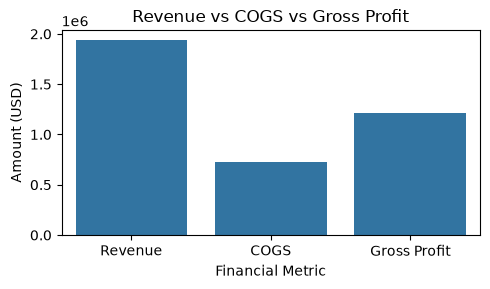

In [14]:
financial_data = pd.DataFrame({"Metric": ["Revenue","COGS","Gross Profit"],"Amount": [total_revenue,total_cogs,gross_profit]})

plt.figure(figsize=(5,3))

sns.barplot(data=financial_data,x="Metric",y="Amount")

plt.title("Revenue vs COGS vs Gross Profit")
plt.xlabel("Financial Metric")
plt.ylabel("Amount (USD)")
plt.tight_layout()
plt.show()

In [15]:
# Revenue Trend
order_items["month"] = (order_items["created_at"].dt.to_period("M"))

monthly_revenue = (order_items.groupby("month")["price_usd"].sum().reset_index())

print("\n----- MONTHLY REVENUE -----")

print(monthly_revenue)


----- MONTHLY REVENUE -----
      month      price_usd
0   2012-03    2999.400101
1   2012-04    4949.010166
2   2012-05    5398.920181
3   2012-06    6998.600235
4   2012-07    8448.310284
5   2012-08   11397.720383
6   2012-09   14347.130482
7   2012-10   18546.290623
8   2012-11   30893.821037
9   2012-12   25294.940849
10  2013-01   19966.100655
11  2013-02   26515.020836
12  2013-03   19896.150646
13  2013-04   28584.470928
14  2013-05   29364.290958
15  2013-06   30544.070995
16  2013-07   31143.961014
17  2013-08   31373.921021
18  2013-09   32723.651066
19  2013-10   38242.621239
20  2013-11   46631.021507
21  2013-12   58262.601913
22  2014-01   56568.891865
23  2014-02   66012.521877
24  2014-03   68189.732004
25  2014-04   78725.432287
26  2014-05   88935.272575
27  2014-06   80051.252337
28  2014-07   83288.552425
29  2014-08   84716.082430
30  2014-09   92232.492651
31  2014-10  103905.982977
32  2014-11  128162.983679
33  2014-12  144823.024078
34  2015-01  132211.543613

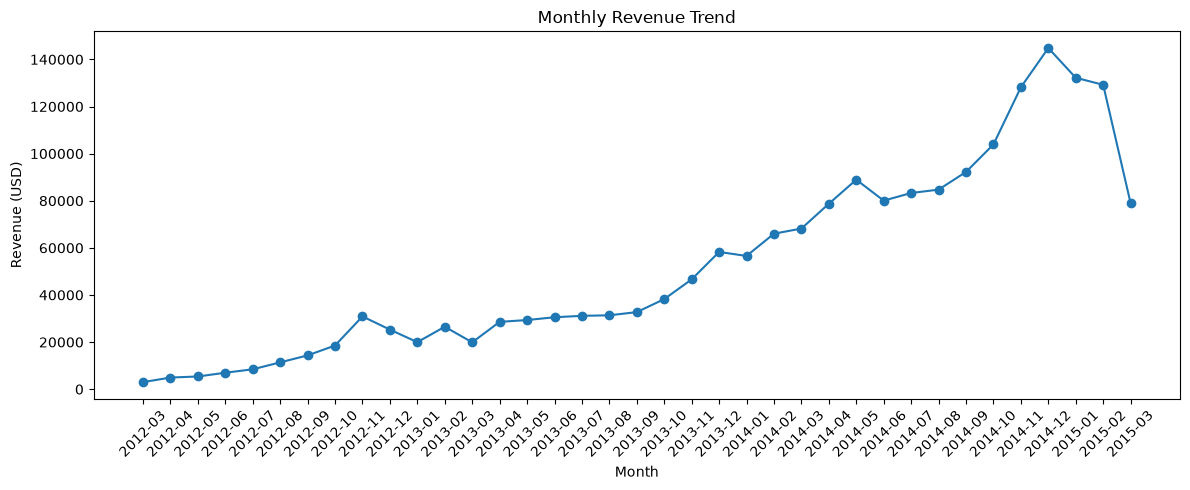

In [16]:
monthly_revenue["month"] = monthly_revenue["month"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["month"],monthly_revenue["price_usd"],marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

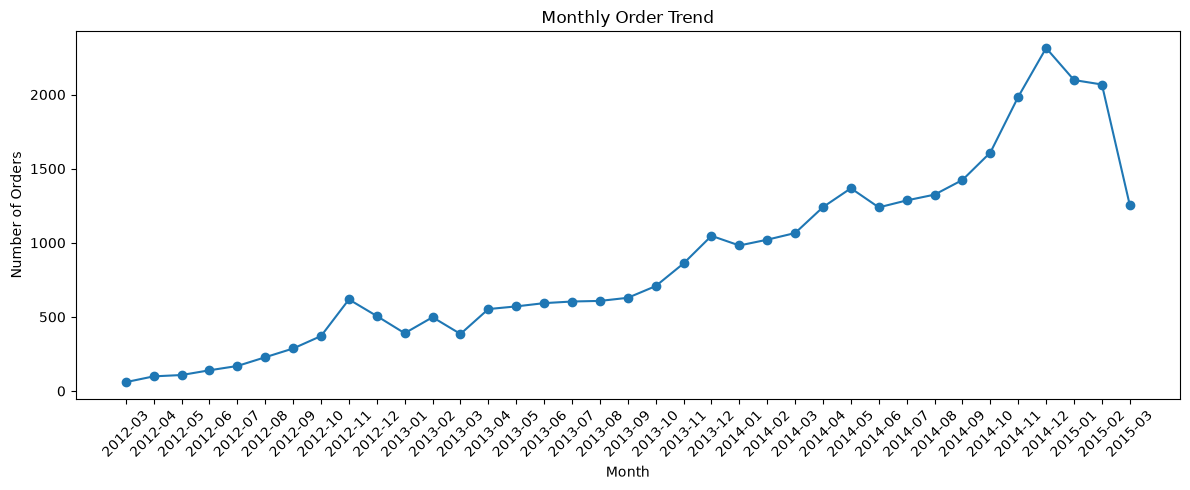

In [17]:
monthly_orders = (orders.assign(month=orders["created_at"].dt.to_period("M")).groupby("month")["order_id"].nunique().reset_index(name="orders"))

monthly_orders["month"] = monthly_orders["month"].astype(str)

plt.figure(figsize=(12, 5))

plt.plot(monthly_orders["month"],monthly_orders["orders"],marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Website Performance
total_sessions = sessions["website_session_id"].nunique()

total_users = sessions["user_id"].nunique()

total_pageviews = pageviews["website_pageview_id"].nunique()

conversion_rate = (total_orders / total_sessions) * 100


print("\n----- WEBSITE KPIs -----")

print("Total Sessions:", total_sessions)

print("Unique Website Users:", total_users)

print("Total Pageviews:", total_pageviews)

print("Conversion Rate:",round(conversion_rate, 2),"%")



----- WEBSITE KPIs -----
Total Sessions: 472871
Unique Website Users: 394318
Total Pageviews: 1188124
Conversion Rate: 6.83 %


In [19]:
# Device Performance
device_sessions = (sessions.groupby("device_type")["website_session_id"].nunique().reset_index(name="sessions"))

print("\n----- SESSIONS BY DEVICE -----")

print(device_sessions)


----- SESSIONS BY DEVICE -----
  device_type  sessions
0     desktop    327027
1      mobile    145844


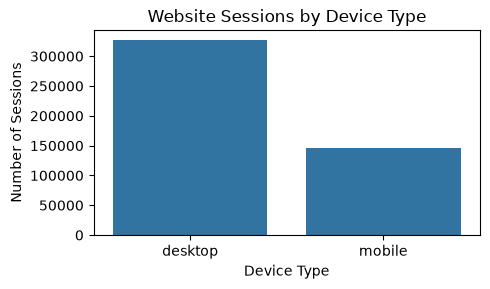

In [20]:
plt.figure(figsize=(5, 3))

sns.barplot(data=device_sessions,x="device_type",y="sessions")

plt.title("Website Sessions by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

In [21]:
# Marketing Analysis
source_sessions = (sessions.groupby("utm_source")["website_session_id"].nunique().reset_index(name="sessions"))

print("\n----- SESSIONS BY MARKETING SOURCE -----")

print(source_sessions)


----- SESSIONS BY MARKETING SOURCE -----
   utm_source  sessions
0        NULL     83328
1     bsearch     62823
2     gsearch    316035
3  socialbook     10685


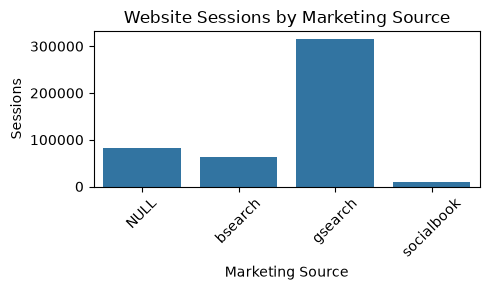

In [22]:
plt.figure(figsize=(5, 3))

sns.barplot(data=source_sessions,x="utm_source",y="sessions")

plt.title("Website Sessions by Marketing Source")
plt.xlabel("Marketing Source")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Repeat sessioon analysis
repeat_sessions = (sessions.groupby("is_repeat_session")["website_session_id"].nunique().reset_index(name="sessions"))

print("\n----- NEW VS REPEAT SESSIONS -----")

print(repeat_sessions)


----- NEW VS REPEAT SESSIONS -----
   is_repeat_session  sessions
0                  0    394318
1                  1     78553


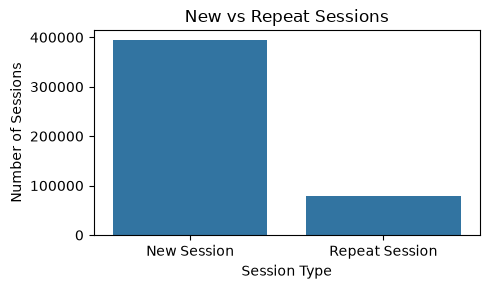

In [24]:
repeat_sessions["session_type"] = (repeat_sessions["is_repeat_session"].map({0: "New Session",1: "Repeat Session"}))

plt.figure(figsize=(5,3))

sns.barplot(data=repeat_sessions,x="session_type",y="sessions")

plt.title("New vs Repeat Sessions")
plt.xlabel("Session Type")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

In [25]:
# Refund Analysis
total_refund = refunds["refund_amount_usd"].sum()

refund_rate = (total_refund / total_revenue) * 100

print("\n----- REFUND KPIs -----")

print("Total Refund Amount:",round(total_refund, 2))

print("Refund Rate:",round(refund_rate, 2),"%")


----- REFUND KPIs -----
Total Refund Amount: 85338.69
Refund Rate: 4.4 %


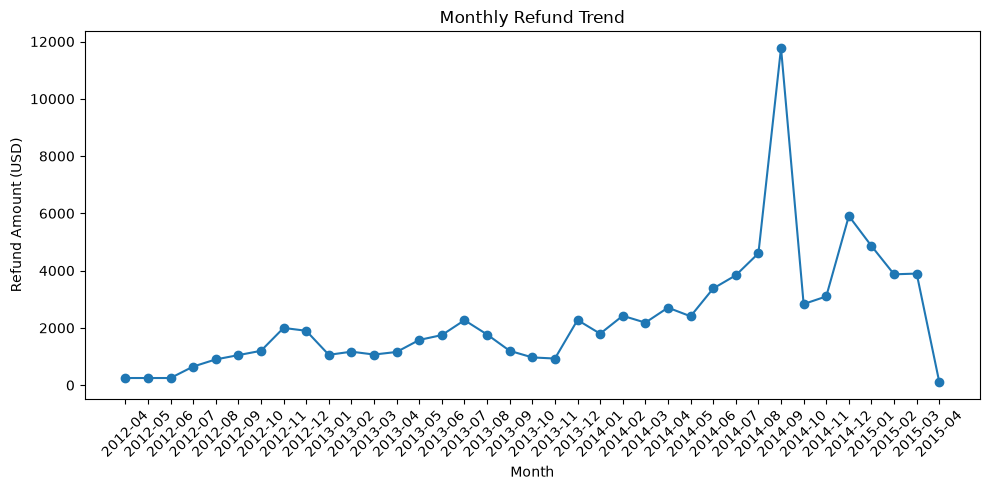

In [26]:
refunds["month"] = (refunds["created_at"].dt.to_period("M"))

monthly_refunds = (refunds.groupby("month")["refund_amount_usd"].sum().reset_index())

monthly_refunds["month"] = (monthly_refunds["month"].astype(str))

plt.figure(figsize=(10,5))

plt.plot(monthly_refunds["month"],monthly_refunds["refund_amount_usd"],marker="o")

plt.title("Monthly Refund Trend")
plt.xlabel("Month")
plt.ylabel("Refund Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Product Performance
product_performance = (order_items.groupby("product_id").agg(orders=("order_id", "nunique"),revenue=("price_usd", "sum"),cogs=("cogs_usd", "sum")).reset_index())

product_performance["gross_profit"] = (product_performance["revenue"] - product_performance["cogs"])

product_performance = (product_performance.merge( products[["product_id", "product_name"]],on="product_id",how="left"))

product_performance = (product_performance.sort_values( "revenue", ascending=False))

print("\n----- TOP PRODUCTS -----")

print(product_performance.head(10))


----- TOP PRODUCTS -----
   product_id  orders       revenue           cogs   gross_profit  \
0           1   24226  1.211058e+06  472164.734455  738893.046207   
1           2    5796  3.477020e+05  130352.038673  217350.011055   
2           3    4985  2.292602e+05   72232.648859  157027.509508   
3           4    5018  1.504898e+05   47620.818851  102869.000000   

                 product_name  
0      The Original Mr. Fuzzy  
1       The Forever Love Bear  
2    The Birthday Sugar Panda  
3  The Hudson River Mini bear  


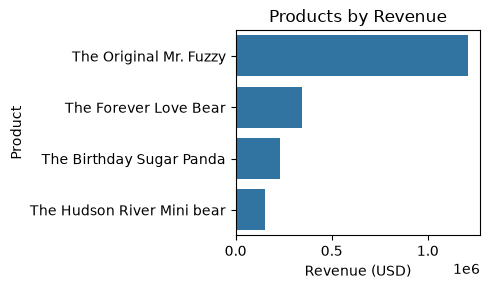

In [28]:
top_products = (product_performance.sort_values("revenue",ascending=False).head(10))

plt.figure(figsize=(5,3))

sns.barplot(data=top_products,y="product_name",x="revenue")

plt.title("Products by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

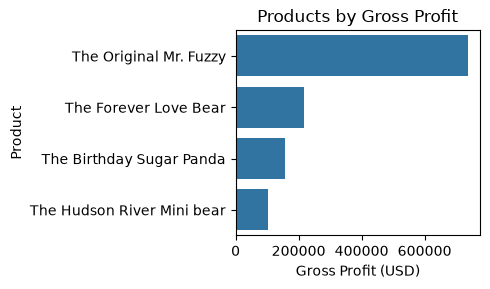

In [29]:
top_profit_products = (product_performance.sort_values("gross_profit",ascending=False).head(10))

plt.figure(figsize=(5,3))

sns.barplot(data=top_profit_products,y="product_name",x="gross_profit")

plt.title("Products by Gross Profit")
plt.xlabel("Gross Profit (USD)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [30]:
# Monthly sales data
monthly_analysis = (order_items.assign(month=order_items["created_at"].dt.to_period("M")).groupby("month").agg(revenue=("price_usd", "sum"),cogs=("cogs_usd", "sum"),orders=("order_id", "nunique")).reset_index())

# Monthly sessions
monthly_sessions = (sessions.assign(month=sessions["created_at"].dt.to_period("M")).groupby("month").agg(sessions=("website_session_id", "nunique")).reset_index())

# Merge
monthly_analysis = monthly_analysis.merge(monthly_sessions,on="month",how="left")

# Correlation
correlation = monthly_analysis[["revenue", "cogs", "orders", "sessions"]].corr()

print(correlation)

           revenue      cogs    orders  sessions
revenue   1.000000  0.999862  0.997020  0.980152
cogs      0.999862  1.000000  0.997911  0.981874
orders    0.997020  0.997911  1.000000  0.983797
sessions  0.980152  0.981874  0.983797  1.000000


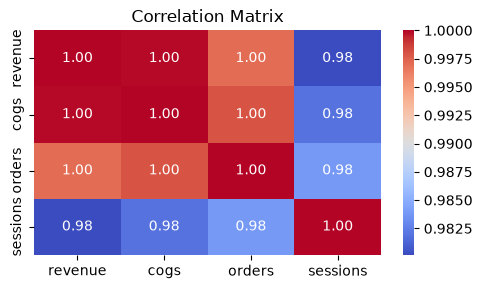

In [31]:
plt.figure(figsize=(5,3))

sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

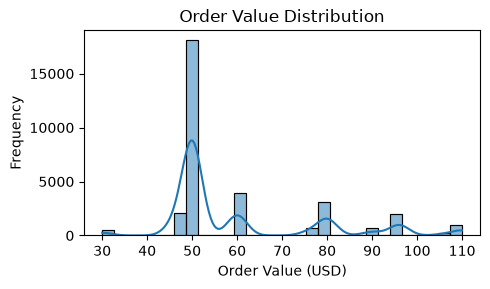

In [32]:
order_values = (order_items.groupby("order_id")["price_usd"].sum().reset_index(name="order_value"))

plt.figure(figsize=(5,3))
sns.histplot(order_values["order_value"],bins=30,kde=True)

plt.title("Order Value Distribution")
plt.xlabel("Order Value (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Predictive Modelling


In [33]:
# create target variable
purchase_sessions = set(orders["website_session_id"].dropna())
sessions["purchase"] = (sessions["website_session_id"].isin(purchase_sessions).astype(int))
print(sessions["purchase"].value_counts())
print(sessions["purchase"].value_counts(normalize=True))


purchase
0    440558
1     32313
Name: count, dtype: int64
purchase
0    0.931666
1    0.068334
Name: proportion, dtype: float64


In [34]:
# feature engineering
pageview_count = (pageviews.groupby("website_session_id").size().reset_index(name="total_pageviews"))
sessions = sessions.merge(pageview_count,on="website_session_id",how="left")
sessions["total_pageviews"] = (sessions["total_pageviews"].fillna(0))


In [35]:
# date based features
sessions["hour"] = (sessions["created_at"].dt.hour)
sessions["day_of_week"] = (sessions["created_at"].dt.dayofweek)
sessions["month"] = (sessions["created_at"].dt.month)

In [36]:
# select features
features = ["is_repeat_session","utm_source","utm_campaign","utm_content","device_type","http_referer","total_pageviews","hour","day_of_week","month"]
X = sessions[features]

y = sessions["purchase"]


In [37]:
from sklearn.model_selection import train_test_split

In [38]:
numerical_features = ["is_repeat_session","total_pageviews","hour","day_of_week","month"]
categorical_features = ["utm_source","utm_campaign","utm_content","device_type","http_referer"]

# Train-test Split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify=y)

In [39]:
X_train.shape, X_test.shape

((331009, 10), (141862, 10))

In [40]:
y_train.shape, y_test.shape

((331009,), (141862,))

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [42]:
# Numerical preprocessing
numerical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])
# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[("num",numerical_pipeline,numerical_features),("cat",categorical_pipeline,categorical_features)])

In [43]:
from sklearn.ensemble import RandomForestClassifier


In [44]:
# Random Forest Model
random_forest_model = Pipeline(steps=[("preprocessor",preprocessor),("classifier",RandomForestClassifier(n_estimators=200,random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

In [45]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['is_repeat_session','utm_source','utm_campaign',...,'hour','day_of_week', 'month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [46]:
rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]


In [47]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve)


In [48]:
# Random Forest Evaluation
rf_accuracy = accuracy_score(y_test,rf_predictions)
rf_precision = precision_score(y_test,rf_predictions,zero_division=0)
rf_recall = recall_score(y_test,rf_predictions,zero_division=0)
rf_f1 = f1_score(y_test,rf_predictions,zero_division=0)
rf_roc_auc = roc_auc_score(y_test,rf_probabilities)

In [49]:
print("Accuracy:",round(rf_accuracy, 4))
print("Precision:",round(rf_precision, 4))
print("Recall:",round(rf_recall, 4))
print("F1 Score:",round(rf_f1, 4))
print("ROC-AUC:",round(rf_roc_auc, 4))
print("\nClassification Report:")
print(classification_report(y_test,rf_predictions,zero_division=0))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132168
           1       1.00      1.00      1.00      9694

    accuracy                           1.00    141862
   macro avg       1.00      1.00      1.00    141862
weighted avg       1.00      1.00      1.00    141862



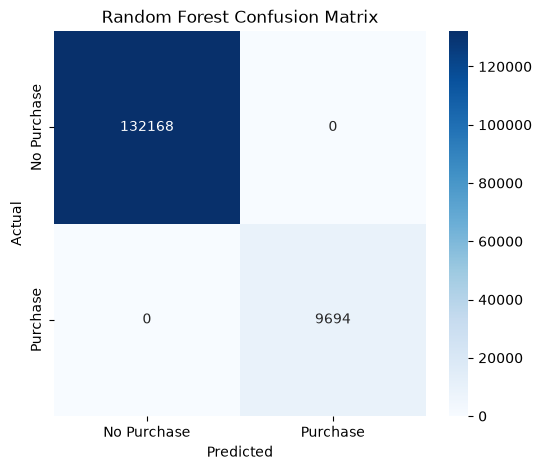

In [50]:
# Confusion Metrix
cm = confusion_matrix(y_test,rf_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Purchase","Purchase"],yticklabels=["No Purchase","Purchase"])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

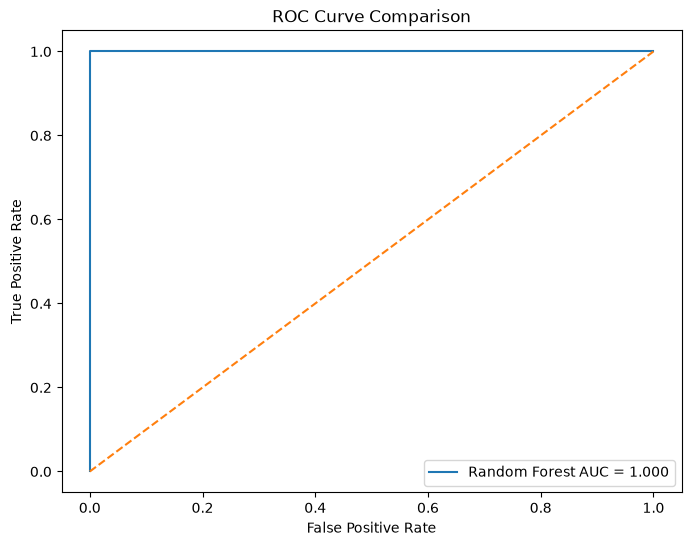

In [51]:
# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test,rf_probabilities)
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr,rf_tpr,label=f"Random Forest AUC = {rf_roc_auc:.3f}")
plt.plot([0, 1],[0, 1],linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [52]:
# Feature Importance
rf_classifier = (random_forest_model.named_steps["classifier"])
rf_preprocessor = (random_forest_model.named_steps["preprocessor"])
feature_names = (rf_preprocessor.get_feature_names_out())
feature_importance = pd.DataFrame({"Feature": feature_names,"Importance":rf_classifier.feature_importances_})
feature_importance = (feature_importance.sort_values("Importance",ascending=False).head(15))
print(feature_importance)


                                         Feature  Importance
1                           num__total_pageviews    0.968441
21                      cat__device_type_desktop    0.013914
22                       cat__device_type_mobile    0.010870
2                                      num__hour    0.001567
4                                     num__month    0.001308
3                               num__day_of_week    0.000818
19                  cat__utm_content_social_ad_1    0.000541
13                       cat__utm_campaign_pilot    0.000521
0                         num__is_repeat_session    0.000438
26  cat__http_referer_https://www.socialbook.com    0.000323
8                     cat__utm_source_socialbook    0.000307
12                    cat__utm_campaign_nonbrand    0.000164
10                       cat__utm_campaign_brand    0.000111
14                         cat__utm_content_NULL    0.000094
9                         cat__utm_campaign_NULL    0.000079


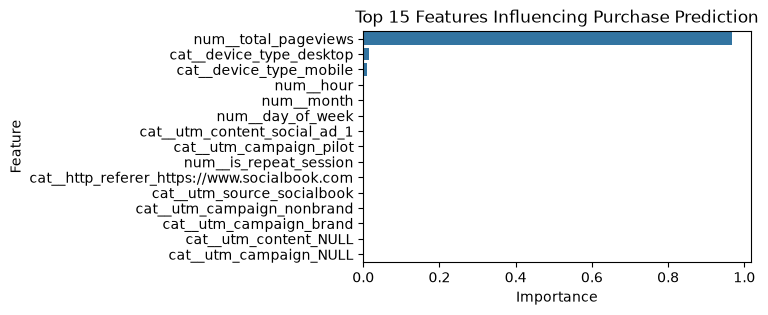

In [53]:
# Feature importance Visualization
plt.figure(figsize=(5, 3))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Top 15 Features Influencing Purchase Prediction")
plt.show()

In [54]:
# Predict purchasing probabilities
prediction_result = X_test.copy()
prediction_result["Actual_Purchase"] = y_test.values
prediction_result["Purchase_Probability"] = rf_probabilities
prediction_result["Predicted_Purchase"] = rf_predictions
print(prediction_result.head(10))

        is_repeat_session utm_source utm_campaign utm_content device_type  \
216095                  0    gsearch     nonbrand      g_ad_1     desktop   
410468                  0    gsearch     nonbrand      g_ad_1     desktop   
373205                  0    bsearch     nonbrand      b_ad_1     desktop   
439123                  0       NULL         NULL        NULL     desktop   
252911                  0       NULL         NULL        NULL     desktop   
126719                  0    gsearch     nonbrand      g_ad_1     desktop   
381727                  0    bsearch     nonbrand      b_ad_1      mobile   
430959                  0    gsearch     nonbrand      g_ad_1     desktop   
48707                   0    bsearch     nonbrand      b_ad_1     desktop   
409585                  0       NULL         NULL        NULL     desktop   

                   http_referer  total_pageviews  hour  day_of_week  month  \
216095  https://www.gsearch.com                7    10            2      3

In [55]:
import joblib

joblib.dump(
    random_forest_model,
    "purchase_prediction_model.pkl"
)

['purchase_prediction_model.pkl']

In [56]:
def predict_purchase(
    is_repeat_session,
    utm_source,
    utm_campaign,
    utm_content,
    device_type,
    http_referer
):

    input_data = pd.DataFrame({
        "is_repeat_session": [is_repeat_session],
        "utm_source": [utm_source],
        "utm_campaign": [utm_campaign],
        "utm_content": [utm_content],
        "device_type": [device_type],
        "http_referer": [http_referer]
    })

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(
        input_data
    )[0][1]

    return prediction, probability